<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/2_finite_differece_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [ ]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Mounted at /content/drive


# Finite-difference method

In general to solve a PDE, we divide the space up into a **laticce** an solve the field $u(\vec{r})$ at each site of the lattie. We will express derivatives in terms od finite differences in the values of $u$ at the laticce sites.

To derive the algorith we will use the Poisson and Laplace's equation as an example. We star by adding the Taylor expansions for $u(x,y)$:

* Derivate to the right:
\begin{align}
u(x+\Delta x,y) = u(x,y) + \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\partial^2 u}{2\partial x^2}(\Delta x)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x-\Delta x,y) = u(x,y) - \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\partial^2 u}{2\partial x^2}(\Delta x)^2 - \cdots\,.
\end{align}

If we add this expressions the odd term cancel up. Notice that we eliminated the firts derivative of the field.

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}\approx \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2}\,,
\end{align}
similarly foy $y$ variable
\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial y^2}\approx \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\,,
\end{align}

## 1. Poisson and Laplace's equation

The Poisson's equation is:
\begin{align}
\boxed{
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} = -4\pi\rho(x,y)} \,,
\end{align}
let's expresed in finite diferences.

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} \approx& \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2} +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\\ \approx& -4\pi\rho(x,y) \,.
\end{align}

If we assume equal spacing in the grid $\Delta x = \Delta y =\Delta$, the algorithm takes a simple form:

\begin{align}
u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)-4u(x,y) = -4\pi\rho(x,y)\Delta^2 \,.
\end{align}

To ilustrate the method we will use the Laplace's equation in the contxt of the electric potential $u(x,y)$ ($\rho\to 0$). The elctric charge, which are the souce of fields, enters indirectly in values of the electric potential in some regions of space. Let's consider the grid:



A survey of Computational physics (Manuel Paez book)


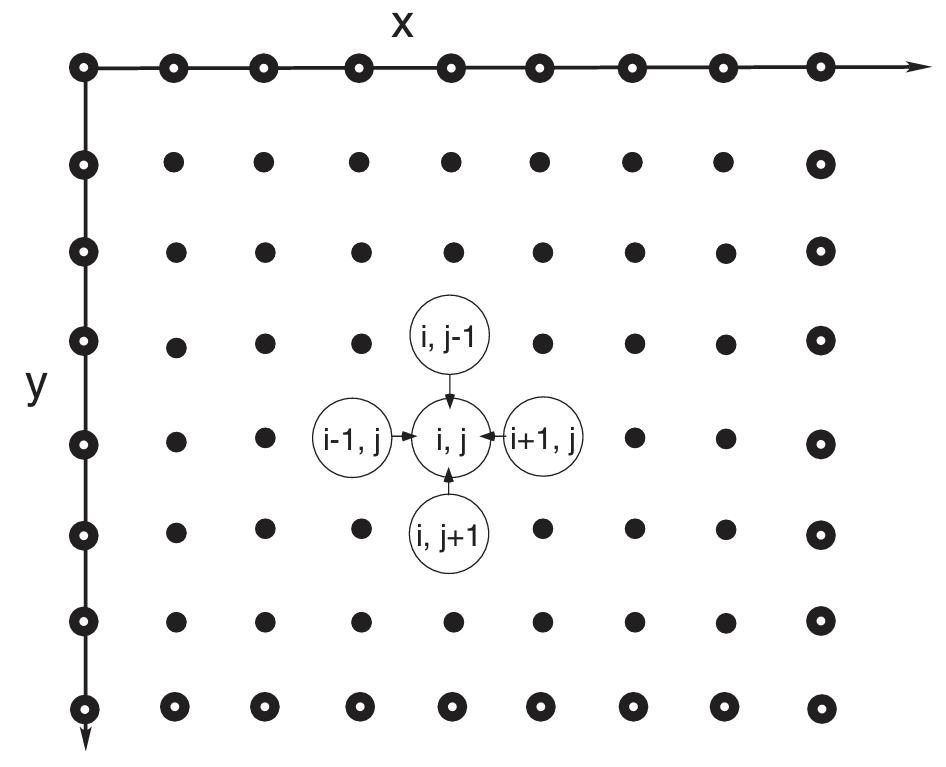

In [ ]:
print('A survey of Computational physics (Manuel Paez book)')
from IPython.display import Image
Image(filename=path+filename3, width=400)

To simplifie the notation and to use a compact and discrete notation, let's be: $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $\{i,j\}=0,\cdots N$. The latter Laplace's equation can be writeen as:

\begin{align}
u(x,y) = \dfrac{1}{4} \left( u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)\right)\,.
\end{align}
In terms of finite differences:
\begin{align}
\boxed{
u_{i,j} = \dfrac{1}{4} \big[ u_{i+1,j}+u_{i-1,j} +
u_{i,j+1}+u_{i,j-1} \big]}\,
\end{align}

This equation expresed the Laplace's equation. It says that the solution at the site $(i,j)$ is the average of the potential at four nearest neighbors as is shown in last figure, $u_{i,j}=u(x_i,y_j)$. We must star  with a initian condition (guest) to the potential, improved it by sweeping through all space taking acount the nearest neighbors at each nodo in the grid. Repeat the process until the solution not longer change to some level of precision (tolerance) or failure.

Does it always converge? how fast?... we will se latter. The relaxation methods converge slowly, although still faster than a Fourier series (Paez, Landau).

## Relaxation

The basic form to interated the last equation is the **Jacobi method** in which the potential values are not change until an entire sweep of applying the last equation to each point is completed.

To accelerated the convergence, which in tirn leads to less round-off error, we can use the technique,knows as **Gauss-Seidel (GS) method**. In terms of finite differences (see references):

\begin{align}
u_{i,j}^{\text{new}} = \dfrac{1}{4} \big[ u_{i+1,j}^{\text{old}}+u_{i-i,j}^{\text{new}} +
u_{i,j+1}^{\text{old}}+u_{i,j-1}^{\text{new}} \big]\,.
\end{align}

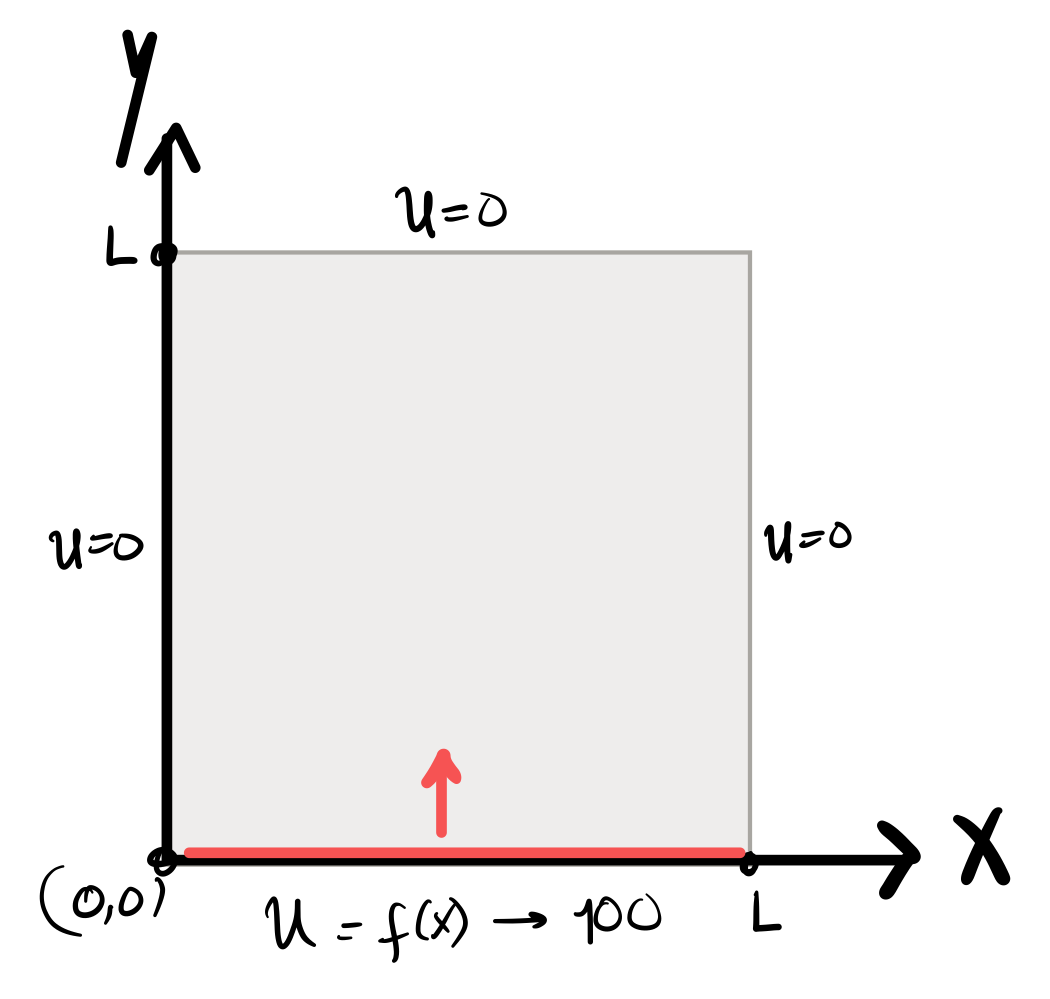

In [ ]:
from IPython.display import Image
Image(filename=path+filename2, width=300)

### Example 1: Solve the Laplace's equation
Let's use the **Jacobi method** to solve the **Laplace's equation** in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

Not continuous in the corners (y=0,L).

To solve the Laplace's equation we set the lenght plate $L=N\Delta = 100$ and $\Delta=1$. Also, we interact the algorithm $N_\text{iter}$ times.
 \begin{align}
 u(i,N) =\, & 99\,, \text{bottom} \hspace{1 cm} u(0,j) =\,0\,, \text{left} \\
 u(N,j) =\, & 0\,, \text{right} \hspace{1.7 cm} u(i,0) =\,0\,, \text{top}\,.
 \end{align}

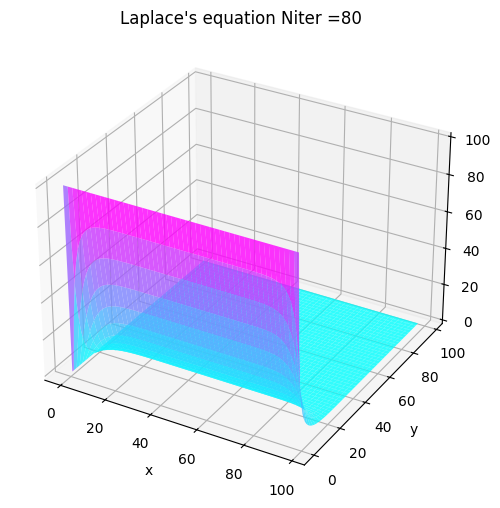

In [ ]:
#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
Nmax, Niter = 100, 80

V = np.zeros((Nmax, Nmax), float) # grid in 0V.

for k in range(0, Nmax):
  V[k,0] = 100.0 # let line at 100V

for iter in range(Niter): # iterations over algorithm. Niter times
  for i in range(1, Nmax-1):
    for j in range(1,Nmax-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

#Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x
X, Y = np.meshgrid(x,y)

def functz(V,X,Y): # Function returns V(x, y)
  z = V[X,Y]
  return z

Z = functz(V,X,Y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### Laplace 2D general rutine

In [ ]:
#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
def Laplace2D(V_ini,Niter,x,y):
  '''Int the V initial configutaration.\n Niter is the number of the itertions of the algorithm.
  x(y) the array in x(y) variable.
  Return X,Y,Z evolve Niter times using finite differences for the Laplace case.'''

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for iter in range(Niter): # iterations over algorithm. Niter times
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

  X, Y = np.meshgrid(x,y)

  Z = V[X,Y] #filed value
  #retunr grid
  return X,Y,Z

Let's do the example again (using the rutine):

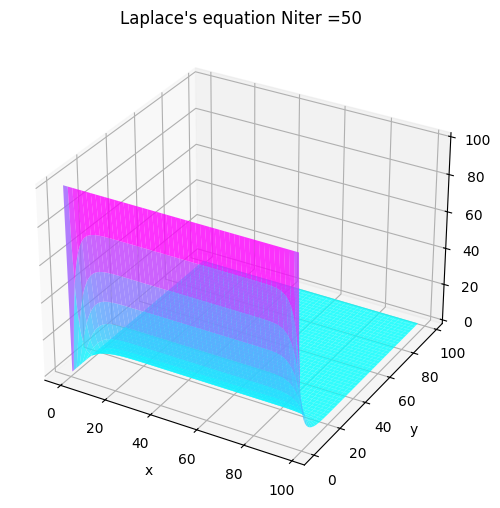

In [ ]:
Nmax, Niter = 100, 50

#Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100.0 # let line at 100V

#Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]

#Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Behaviour with the number of iteration of the algoritm.

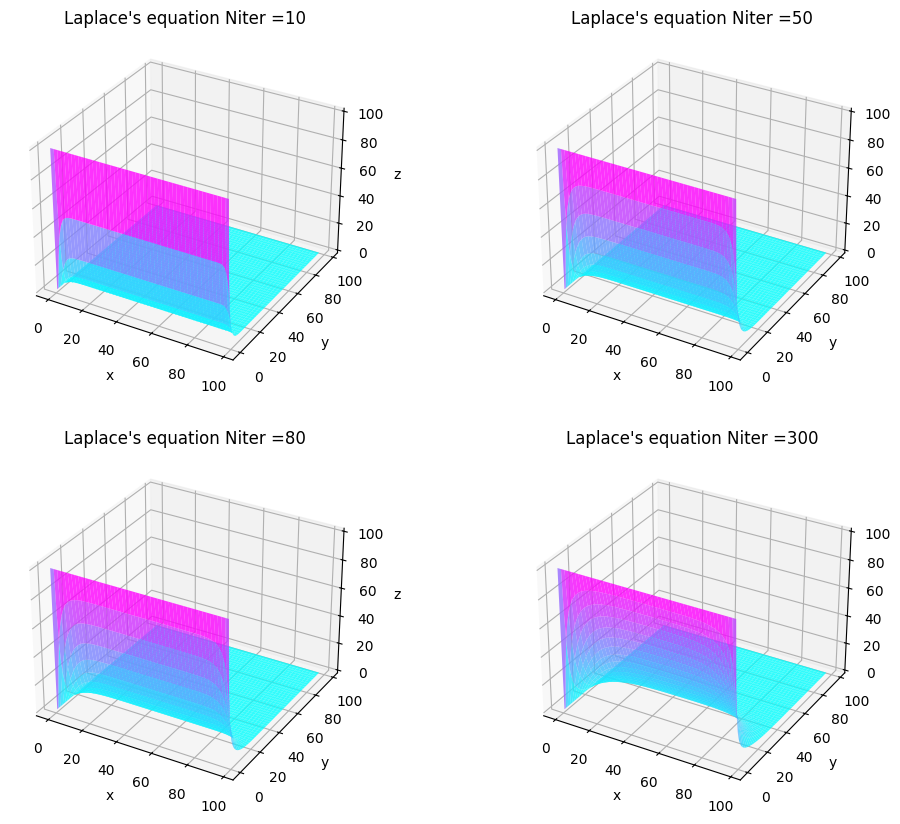

In [ ]:
fig, ax= plt.subplots(2,2, subplot_kw={'projection': '3d'},figsize=(12,10))
#************************************
Nmax, Niter = 100, 10
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[0,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,0].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 50
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[0,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,1].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_zlabel('z')
#************************************
Nmax, Niter = 100, 80
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[1,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,0].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('y')
ax[1,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 300
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[1,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,1].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')
ax[1,1].set_zlabel('z')
#************************************

plt.show()

#### Exercise 1: Lab1_3: finite-differences with tolerance

* Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
* Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
* Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### Exercise 2: Lab1_4: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

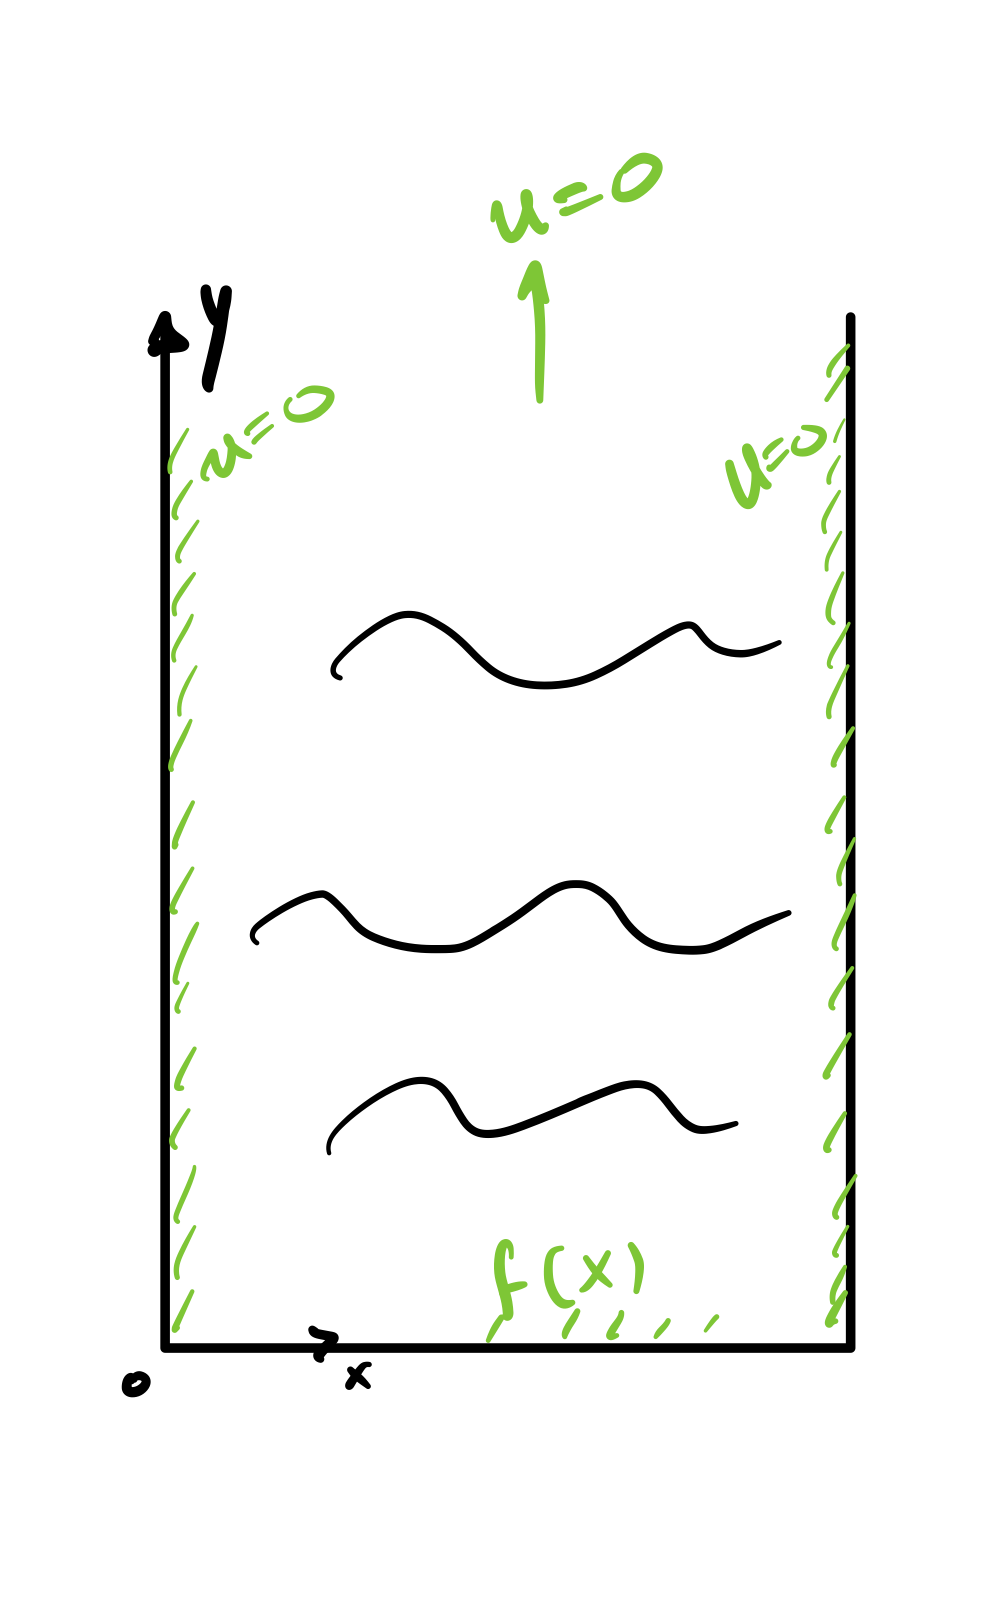

In [ ]:
from IPython.display import Image
Image(filename=path+filename4, width=200)

### Example 2: Electric field in a capacitor

in process...

## 2. Diffusion equation

\begin{align}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{\partial^2 u(x,y,t)}{\partial x^2} +\dfrac{\partial^2 u(x,y,t)}{\partial y^2}= \dfrac{1}{\alpha}\dfrac{\partial u(x,y,t)}{\partial t}}
\end{align}

Where $1/\alpha$ is the diffusion coefficient. Here, we will express derivatives in terms of finite differences in the values of $u$ at the laticce sites. For space coordinates in 2D:


\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} \approx& \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2} +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2} \,.
\end{align}

For time:
* Derivate to the right:
\begin{align}
u(x,y,t+\Delta t) = u(x,y,t) + \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x,y,t-\Delta t) = u(x,y,t) - \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots\,,
\end{align}
* Central derivative:
\begin{align}
\dfrac{\partial u}{\partial t} \approx \dfrac{u(x,y,t+\Delta t) -u(x,y,t-\Delta t)}{2\Delta t} \,.
\end{align}

Let's suppose $\Delta x=\Delta y$, $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $t_k=k\Delta t$, $\{i,j,k\}=0,\cdots N$. Using the derivative to the right (forward in time), the Diffusion's equation can be writeen as:

\begin{align}
\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}
= \dfrac{1}{\alpha}\dfrac{\big(u_{i,j,k+1}-u_{i,j,k}\big)}{\Delta t}\,,
\end{align}
and the state of the system at time step $k$ may be calculated from its state at time step $k$ as:

\begin{align}
\boxed{
u_{i,j,k+1}=u_{i,j,k}+\alpha\Delta t\,\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}} \,.
\end{align}



### Example 1: Heat diffusion in a plate

Consider the diffusion equation applied to a metal plate initially at temperature $T_\text{cold}$  apart from a disc of a specified size which is at temperature $T_\text{hot}$. We suppose that the edges of the plate are held fixed at $T_\text{cold}$. The following code applies the above formula to follow the evolution of the temperature of the plate.

In the code below, each call to `do_timestep` updates the numpy array u from the results of the previous timestep, `u0`. It does not apply directly the algorithm because this runs extremely slowly and using vectorization will farm out these explicit loops to the much faster pre-compiled C-code underlying NumPy's array implementation.

The state of the system is plotted as an image at four different stages of its evolution.

Taken from: https://scipython.com/books/book2/chapter-7-matplotlib/examples/the-two-dimensional-diffusion-equation/


In [16]:
#**************** DIFFUSION EQUATION ******************
def Diffusion2D(V_ini,nx,dt,D):

  u0 = V_ini.copy()

  for i in range(1, nx-1):
      for j in range(1, ny-1):
          uxx = (u0[i+1,j] - 2*u0[i,j] + u0[i-1,j])/dx2
          uyy = (u0[i,j+1] - 2*u0[i,j] + u0[i,j-1])/dy2
          u[i,j] = u0[i,j] + dt*D*(uxx + uyy)
  return u

dt= 0.0006250000000000001
time (s)= 2.952402547999995

figure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms


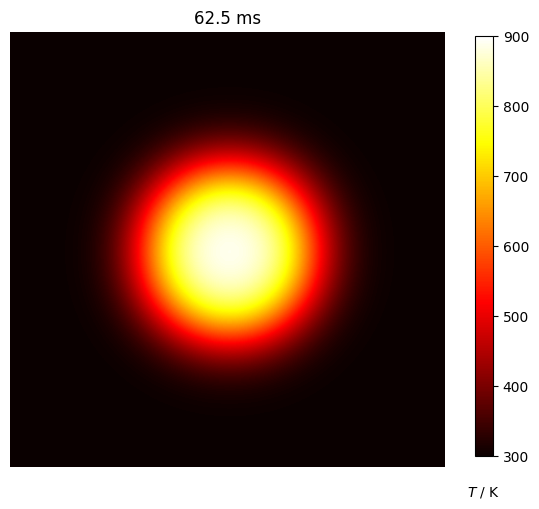

In [26]:
#import numpy as np
#import matplotlib.pyplot as plt

# plate size, mm
w = h = 10.0
# intervals in x-, y- directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1
D = 4.0 #D=1/alpha

Tcool, Thot = 300, 900

nx, ny = int(w / dx), int(h / dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2 / (2*D*(dx2 + dy2)) #maximun t allowed
print('dt=',dt)

u0 = Tcool*np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm) at thot
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

# Number of times teps with dt=0.000625
nsteps = 101
# timesteps.
fig, ax = plt.subplots(figsize=(6,6) )

start = tm.process_time() #Starting time counter for user
#propagate the signal
for m in range(nsteps):
    u = Diffusion2D(u0,nx,dt,D)
    u0 = u.copy()
end = tm.process_time() #Finishing time counter for user
print('time (s)=' ,end-start ) #Storing result

im = ax.imshow(u.copy(),cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()
ax.set_title("{:.1f} ms".format(m*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
print('\nfigure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms')
plt.show()

Better: improved the **slicing rutine in c**... In NumPy, slicing is the process of extracting a subset of elements from an array. It follows the general syntax [start:stop:step], where start is inclusive and stop is exclusive

dt= 0.0006250000000000001
time (s)= 0.011087653000004138

figure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms


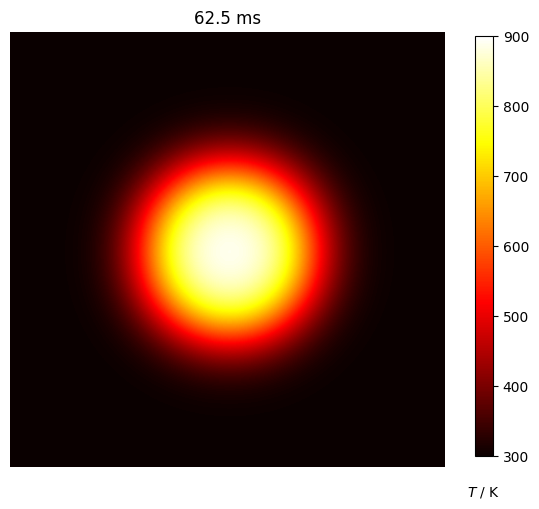

In [27]:
#import numpy as np
#import matplotlib.pyplot as plt

# plate size, mm
w = h = 10.0
# intervals in x-, y- directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1
D = 4.0 #D=1/alpha

Tcool, Thot = 300, 900

nx, ny = int(w / dx), int(h / dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2 / (2*D*(dx2 + dy2)) #maximun t allowed
print('dt=',dt)

u0 = Tcool*np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy and the slicing
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2]- 4*u0[1:-1, 1:-1])/dx2

    u0 = u.copy()
    return u0, u

# Number of times teps with dt=0.000625
nsteps = 101
# timesteps.
mfig = 50
fig, ax = plt.subplots(figsize=(6,6) )

start = tm.process_time() #Starting time counter for user
for m in range(nsteps): #propagate the signal
    u0, u = do_timestep(u0, u)
end = tm.process_time() #Finishing time counter for user
print('time (s)=' ,end-start ) #Storing result

im = ax.imshow(u.copy(),cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()
ax.set_title("{:.1f} ms".format(m*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
print('\nfigure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms')
plt.show()

This system analytical needs the Bessel funtions to do the Fourier series. Let's plot for 4 different times.

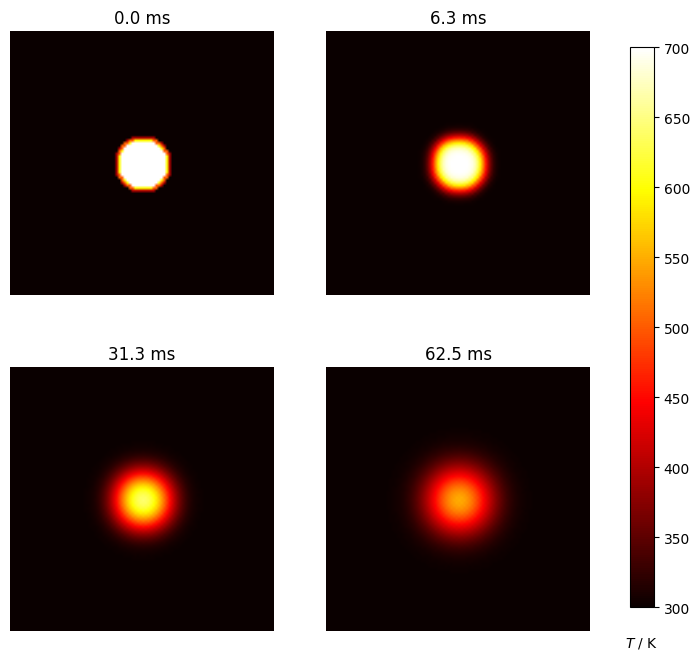

In [32]:
#import numpy as np
#import matplotlib.pyplot as plt

# plate size, mm
w = h = 10.0
# intervals in x-, y- directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1
D = 4.0 #D=1/alpha

Tcool, Thot = 300, 700

nx, ny = int(w / dx), int(h / dy)

dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2 * D * (dx2 + dy2)) #maximun t allowed

u0 = Tcool * np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 1, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] - 4 * u0[1:-1, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2])/dx2

    u0 = u.copy()
    return u0, u

# Number of timesteps.
nsteps = 101
# Output 4 figures at these timesteps.
mfig = [0, 10, 50, 100]
fignum = 0
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8) )
for m in range(nsteps):
    u0, u = do_timestep(u0, u)
    if m in mfig:
        #print(m, fignum)
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(
            u.copy(),
            cmap="hot",
            vmin=Tcool,
            vmax=Thot,
            interpolation="bilinear",
        )
        ax.set_axis_off()
        ax.set_title("{:.1f} ms".format(m * dt * 1000))
        fignum += 1
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

## 3. Wave's equation

\begin{align}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{1}{v^2}\dfrac{\partial^2 u(x,y,t)}{\partial t^2}}
\end{align}